<a href="https://colab.research.google.com/github/SANTHOSH-C08/AI-INTERNSHIP/blob/main/stroke_prediction_using_tensorflow%26keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets

In [ ]:
df= pd.read_csv("/content/healthcare-dataset-stroke-data.csv")

In [ ]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


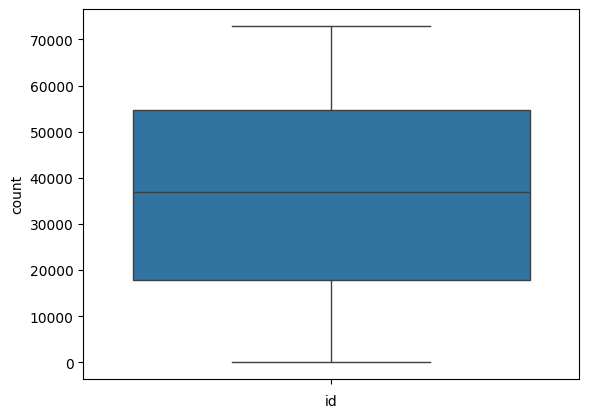

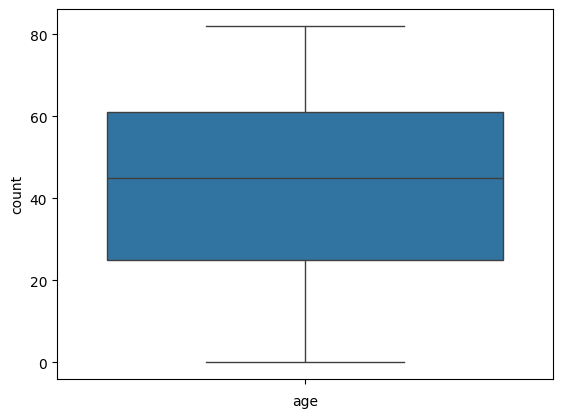

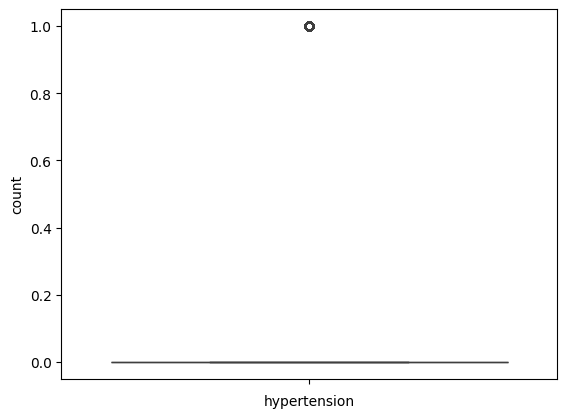

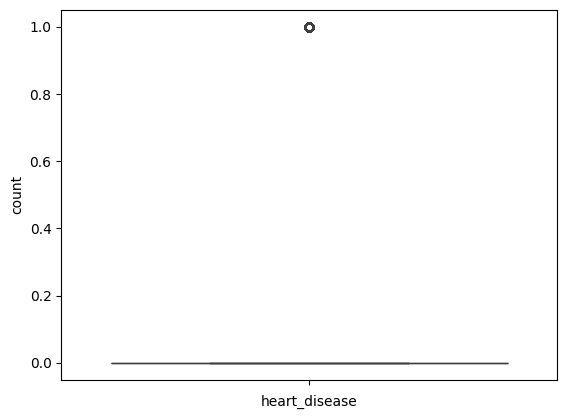

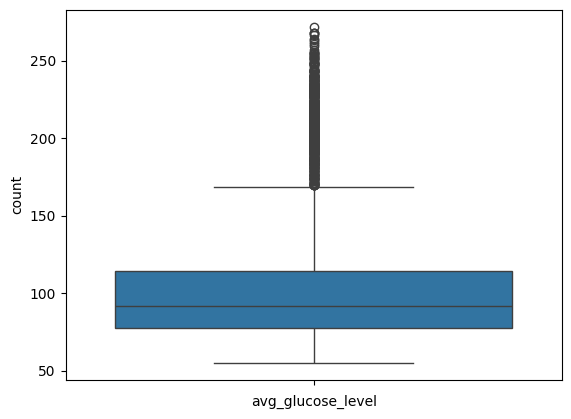

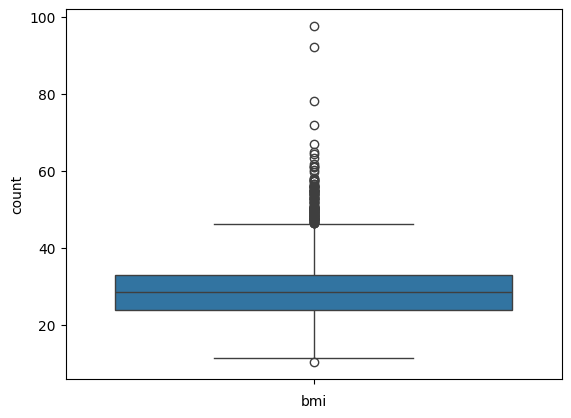

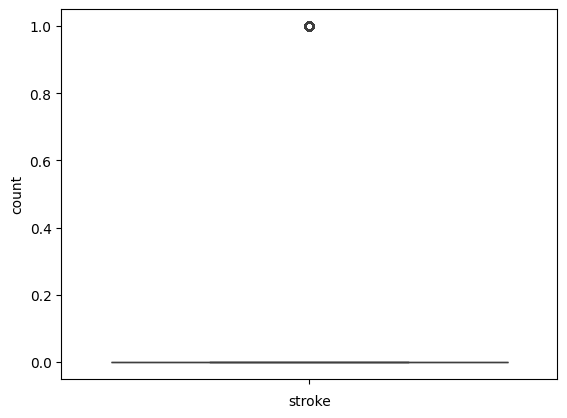

In [ ]:
for i in df.columns:
  if df[i].dtype != 'object':
    sns.boxplot(df[i])
    plt.xlabel(i)
    plt.ylabel('count')
    plt.show()

In [ ]:
df['heart_disease'].value_counts()

,count
heart_disease,
0,4834
1,276


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
col = ['bmi', 'avg_glucose_level']

In [ ]:
for i in col:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3 - q1
  lower_fence = q1 - 1.5*iqr
  upper_fence = q3 + 1.5*iqr
  df = df[(lower_fence<= df[i]) & (upper_fence >= df[i])]

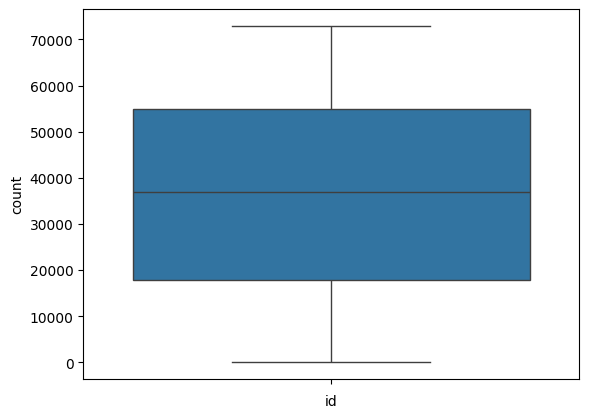

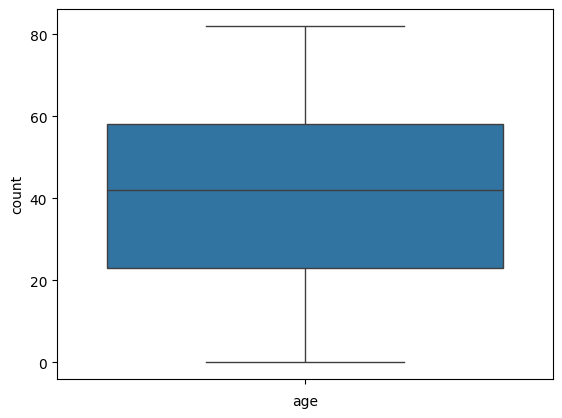

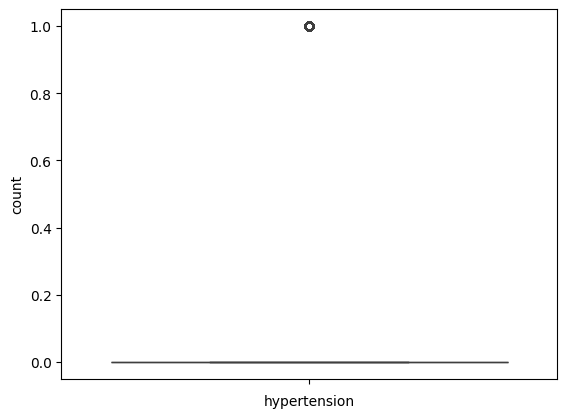

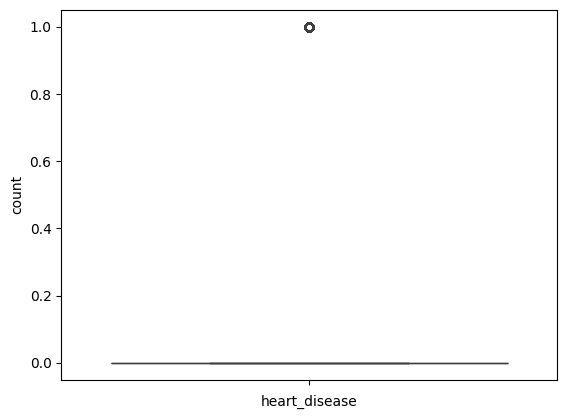

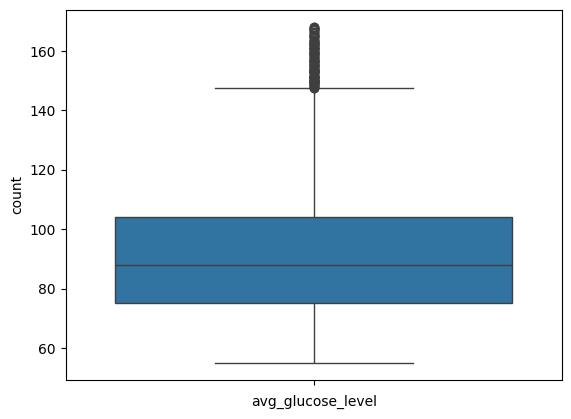

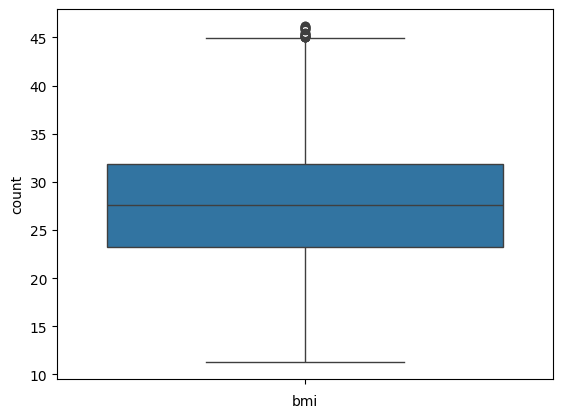

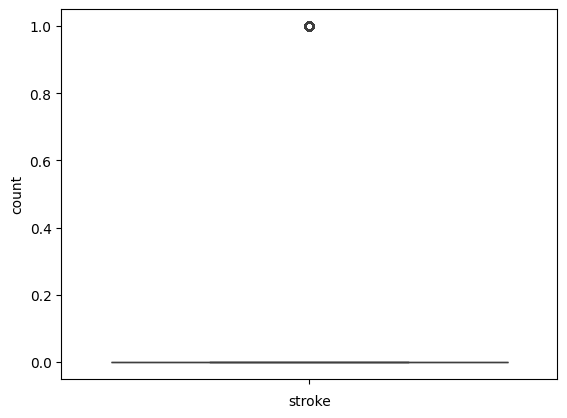

In [ ]:
for i in df.columns:
  if df[i].dtype != 'object':
    sns.boxplot(df[i])
    plt.xlabel(i)
    plt.ylabel('count')
    plt.show()

In [ ]:
for i in col:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3 - q1
  lower_fence = q1 - 1.5*iqr
  upper_fence = q3 + 1.5*iqr
  df = df[(lower_fence<= df[i]) & (upper_fence >= df[i])]

In [ ]:
from sklearn.preprocessing import LabelEncoder
he = LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object":
    df[i] = he.fit_transform(df[i])

In [ ]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5104,14180,0,13.0,0,0,0,4,0,103.08,18.600000,0,0
5105,18234,0,80.0,1,0,1,2,1,83.75,28.893237,2,0
5106,44873,0,81.0,0,0,1,3,1,125.20,40.000000,2,0
5107,19723,0,35.0,0,0,1,3,0,82.99,30.600000,2,0
5109,44679,0,44.0,0,0,1,0,1,85.28,26.200000,0,0


In [ ]:
x = df.iloc[:,:-1]
y = df[["stroke"]]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test ,y_train, y_test = train_test_split(x,y, test_size=0.2, random_state = 42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
for i in x_train.columns:
  if x_train[i].dtypes != "object":
    x_train[i] = sc.fit_transform(x_train[[i]])
xtrain = x_train

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
model = keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(11,)),
        keras.layers.Dense(20, activation='relu'),
        keras.layers.Dense(2, activation ='sigmoid')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
               loss ='sparse_categorical_crossentropy',
               metrics = ['accuracy'])

In [ ]:
history = model.fit(xtrain, y_train, validation_split = 0.1, epochs=30)

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8853 - loss: 0.3573 - val_accuracy: 0.9735 - val_loss: 0.1727
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9634 - loss: 0.1719 - val_accuracy: 0.9765 - val_loss: 0.1115
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9644 - loss: 0.1466 - val_accuracy: 0.9765 - val_loss: 0.0961
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9644 - loss: 0.1381 - val_accuracy: 0.9794 - val_loss: 0.0903
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9640 - loss: 0.1340 - val_accuracy: 0.9794 - val_loss: 0.0878
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9640 - loss: 0.1313 - val_accuracy: 0.9794 - val_loss: 0.0859
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9644 - loss: 0.1295 - val_accuracy: 0.9794 - val_loss: 0.0847
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9640 - loss: 0.1281 - val_accuracy: 0.9794 - val_loss:

Text(0, 0.5, 'epoch')

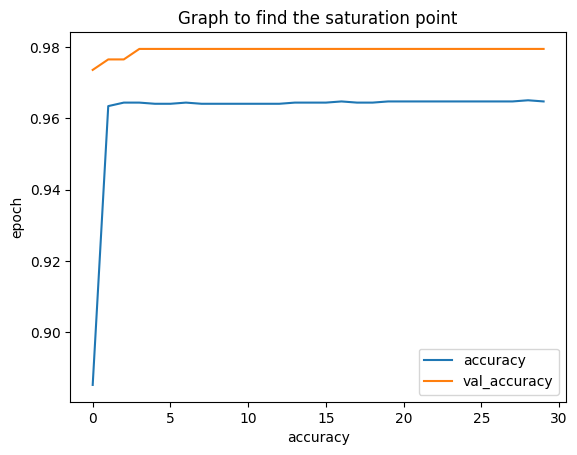

In [ ]:
sns.lineplot(history.history['accuracy'], label='accuracy')
sns.lineplot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Graph to find the saturation point')
plt.xlabel('accuracy')
plt.ylabel('epoch')


Text(0, 0.5, 'val_loss')

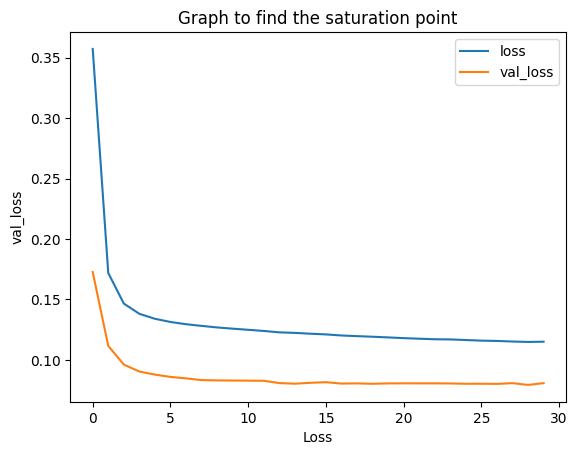

In [ ]:
sns.lineplot(history.history['loss'], label="loss")
sns.lineplot(history.history['val_loss'], label="val_loss")
plt.title('Graph to find the saturation point')
plt.xlabel('Loss')
plt.ylabel('val_loss')
